In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
!pip install -q torch torchvision timm albumentations opencv-python scikit-learn matplotlib seaborn pandas

In [ ]:
import torch
import torchvision
import timm
import albumentations
import cv2
import sklearn
import pandas as pd

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list -s skin disease

usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,benchmarks,b,config,auth} ...
kaggle: error: unrecognized arguments: disease


In [ ]:
!mkdir -p /content/data

In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/data

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [04:07<00:00, 22.6MB/s]



In [ ]:
!mkdir -p /content/data/ham10000
!unzip -q /content/data/skin-cancer-mnist-ham10000.zip -d /content/data/ham10000

In [ ]:
import os

print(os.listdir("/content/data/ham10000"))

['HAM10000_images_part_2', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'hmnist_8_8_L.csv', 'ham10000_images_part_2', 'hmnist_8_8_RGB.csv', 'hmnist_28_28_L.csv', 'ham10000_images_part_1', 'HAM10000_metadata.csv']


In [ ]:
print(os.listdir("/content/data/ham10000"))

['HAM10000_images_part_2', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'hmnist_8_8_L.csv', 'ham10000_images_part_2', 'hmnist_8_8_RGB.csv', 'hmnist_28_28_L.csv', 'ham10000_images_part_1', 'HAM10000_metadata.csv']


In [ ]:
import pandas as pd

metadata_path = "/content/data/ham10000/HAM10000_metadata.csv"

df = pd.read_csv(metadata_path)

print("Number of records:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nDisease distribution:")
print(df["dx"].value_counts())

Number of records: 10015

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Disease distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
print(df[["image_id", "dx", "dx_type"]].head(10))

       image_id   dx dx_type
0  ISIC_0027419  bkl   histo
1  ISIC_0025030  bkl   histo
2  ISIC_0026769  bkl   histo
3  ISIC_0025661  bkl   histo
4  ISIC_0031633  bkl   histo
5  ISIC_0027850  bkl   histo
6  ISIC_0029176  bkl   histo
7  ISIC_0029068  bkl   histo
8  ISIC_0025837  bkl   histo
9  ISIC_0025209  bkl   histo


In [ ]:
import os

base = "/content/data/ham10000"

for root, dirs, files in os.walk(base):
    print("FOLDER:", root)
    print("Number of files:", len(files))
    print("First few files:", files[:5])
    print("-" * 60)

In [ ]:
import glob

jpg_files = glob.glob("/content/data/ham10000/**/*.jpg", recursive=True)

print("Total JPG images found:", len(jpg_files))
print("First 10 images:")

for f in jpg_files[:10]:
    print(f)

Total JPG images found: 0
First 10 images:


In [ ]:
import os

print("Does /content/data exist?", os.path.exists("/content/data"))

if os.path.exists("/content/data"):
    print("\nContents of /content/data:")
    print(os.listdir("/content/data"))

Does /content/data exist? False


In [ ]:
!mkdir -p /content/data

!kaggle datasets download \
-d kmader/skin-cancer-mnist-ham10000 \
-p /content/data

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [04:17<00:00, 21.7MB/s]



In [ ]:
!mkdir -p /content/data/ham10000

!unzip -q /content/data/skin-cancer-mnist-ham10000.zip \
-d /content/data/ham10000

In [ ]:
import os

print(os.listdir("/content/data/ham10000"))

['HAM10000_images_part_2', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'hmnist_8_8_L.csv', 'ham10000_images_part_2', 'hmnist_8_8_RGB.csv', 'hmnist_28_28_L.csv', 'ham10000_images_part_1', 'HAM10000_metadata.csv']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.makedirs('/content/drive/MyDrive/DermaWise/data', exist_ok=True)

print("DermaWise folder created!")

DermaWise folder created!


In [ ]:
!kaggle datasets download \
-d kmader/skin-cancer-mnist-ham10000 \
-p /content/drive/MyDrive/DermaWise/data

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [04:19<00:00, 21.5MB/s]



In [ ]:
!mkdir -p /content/drive/MyDrive/DermaWise/data/ham10000

!unzip -q \
/content/drive/MyDrive/DermaWise/data/skin-cancer-mnist-ham10000.zip \
-d /content/drive/MyDrive/DermaWise/data/ham10000

In [ ]:
import os

base = "/content/drive/MyDrive/DermaWise/data/ham10000"

print(os.listdir(base))

['HAM10000_images_part_1', 'HAM10000_images_part_2', 'HAM10000_metadata.csv', 'ham10000_images_part_1', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_L.csv', 'hmnist_8_8_RGB.csv']


In [ ]:
import pandas as pd

metadata_path = "/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_metadata.csv"

df = pd.read_csv(metadata_path)

print("Total records:", len(df))
print("\nColumns:")
print(df.columns.tolist())

Total records: 10015

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


In [ ]:
print(df["dx"].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
label_names = {
    "akiec": "Actinic keratoses / Bowen's disease",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

for code, count in df["dx"].value_counts().items():
    print(f"{code:6} → {label_names[code]:35} {count} images")

nv     → Melanocytic nevi                    6705 images
mel    → Melanoma                            1113 images
bkl    → Benign keratosis                    1099 images
bcc    → Basal cell carcinoma                514 images
akiec  → Actinic keratoses / Bowen's disease 327 images
vasc   → Vascular lesions                    142 images
df     → Dermatofibroma                      115 images


In [ ]:
import glob

jpg_files = glob.glob(
    "/content/drive/MyDrive/DermaWise/data/ham10000/**/*.jpg",
    recursive=True
)

print("Total JPG images:", len(jpg_files))
print("\nFirst 10:")

for path in jpg_files[:10]:
    print(path)

Total JPG images: 20030

First 10:
/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0024306.jpg
/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0024307.jpg
/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0024308.jpg
/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0024309.jpg
/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0024310.jpg
/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0024311.jpg
/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0024312.jpg
/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0024313.jpg
/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0024314.jpg
/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0024315.jpg


In [ ]:
import os

base = "/content/drive/MyDrive/DermaWise/data/ham10000"

for folder in os.listdir(base):
    path = os.path.join(base, folder)

    if os.path.isdir(path):
        files = os.listdir(path)
        print(f"{folder}: {len(files)} files")

HAM10000_images_part_1: 5000 files
HAM10000_images_part_2: 5015 files
ham10000_images_part_1: 5000 files
ham10000_images_part_2: 5015 files


In [ ]:
import shutil
import os

base = "/content/drive/MyDrive/DermaWise/data/ham10000"

for folder in ["ham10000_images_part_1", "ham10000_images_part_2"]:
    path = os.path.join(base, folder)

    if os.path.exists(path):
        shutil.rmtree(path)
        print("Deleted:", folder)

Deleted: ham10000_images_part_1
Deleted: ham10000_images_part_2


In [ ]:
print(os.listdir(base))

['HAM10000_metadata.csv', 'HAM10000_images_part_1', 'HAM10000_images_part_2']


In [ ]:
import glob

jpg_files = glob.glob(
    "/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_*.jpg"
)

print("Images found:", len(jpg_files))

Images found: 0


In [ ]:
import glob

jpg_files = glob.glob(
    "/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_*/*.jpg"
)

print("Images found:", len(jpg_files))
print(jpg_files[:10])

Images found: 10015
['/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0028308.jpg', '/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0028301.jpg', '/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0028290.jpg', '/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0028277.jpg', '/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0028288.jpg', '/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0028281.jpg', '/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0028304.jpg', '/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0028280.jpg', '/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0028343.jpg', '/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1/ISIC_0028300.jpg']


In [ ]:
import os

base = "/content/drive/MyDrive/DermaWise/data/ham10000"

for folder in os.listdir(base):
    path = os.path.join(base, folder)
    print("\n", folder, "->", os.path.isdir(path))

    if os.path.isdir(path):
        print("First 5 files:", os.listdir(path)[:5])


 HAM10000_metadata.csv -> False

 HAM10000_images_part_1 -> True
First 5 files: ['ISIC_0028308.jpg', 'ISIC_0028301.jpg', 'ISIC_0028290.jpg', 'ISIC_0028277.jpg', 'ISIC_0028288.jpg']

 HAM10000_images_part_2 -> True
First 5 files: ['ISIC_0033320.jpg', 'ISIC_0033332.jpg', 'ISIC_0033378.jpg', 'ISIC_0033344.jpg', 'ISIC_0033318.jpg']


In [ ]:
import glob

folder1 = "/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1"
folder2 = "/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_2"

images1 = glob.glob(folder1 + "/*.jpg")
images2 = glob.glob(folder2 + "/*.jpg")

jpg_files = images1 + images2

print("Part 1:", len(images1))
print("Part 2:", len(images2))
print("TOTAL:", len(jpg_files))

Part 1: 5000
Part 2: 5015
TOTAL: 10015


In [ ]:
import pandas as pd
import os
import glob

# Load metadata
metadata_path = "/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_metadata.csv"
df = pd.read_csv(metadata_path)

print("Total metadata records:", len(df))
print("\nDisease distribution:")
print(df["dx"].value_counts())

Total metadata records: 10015

Disease distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
folder1 = "/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_1"
folder2 = "/content/drive/MyDrive/DermaWise/data/ham10000/HAM10000_images_part_2"

image_paths = {}

for path in glob.glob(folder1 + "/*.jpg") + glob.glob(folder2 + "/*.jpg"):
    image_id = os.path.splitext(os.path.basename(path))[0]
    image_paths[image_id] = path

df["image_path"] = df["image_id"].map(image_paths)

print("Images matched:", df["image_path"].notna().sum())
print("Images missing:", df["image_path"].isna().sum())

Images matched: 10015
Images missing: 0


In [ ]:
label_names = {
    "akiec": "Actinic keratoses",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

for code, count in df["dx"].value_counts().items():
    print(f"{code:6} → {label_names[code]:30} {count}")

nv     → Melanocytic nevi               6705
mel    → Melanoma                       1113
bkl    → Benign keratosis               1099
bcc    → Basal cell carcinoma           514
akiec  → Actinic keratoses              327
vasc   → Vascular lesions               142
df     → Dermatofibroma                 115


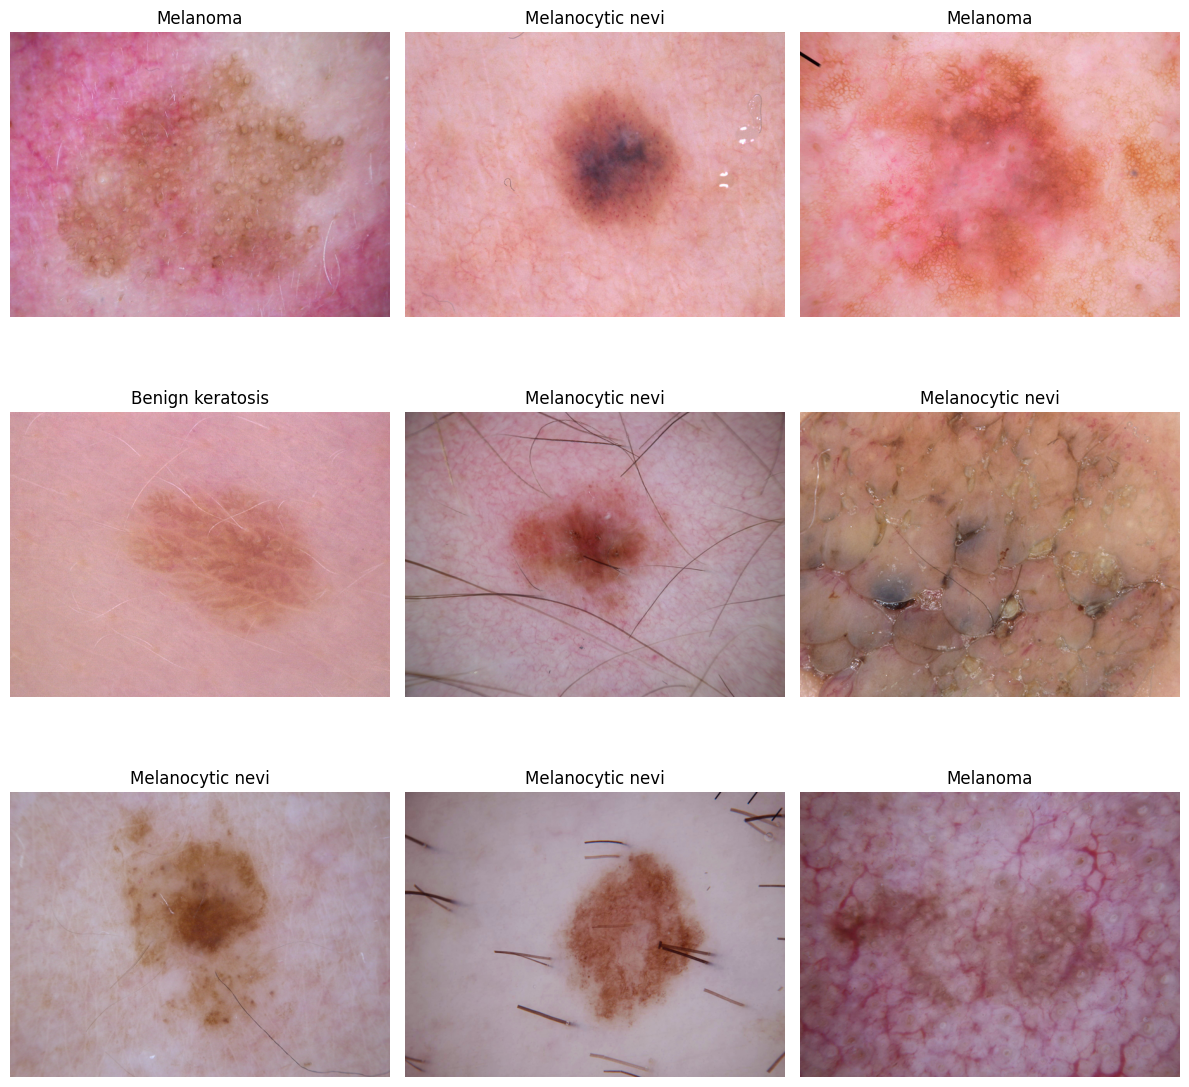

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

samples = df.sample(9, random_state=42)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(samples.iterrows()):
    img = Image.open(row["image_path"])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(label_names[row["dx"]])

plt.tight_layout()
plt.show()

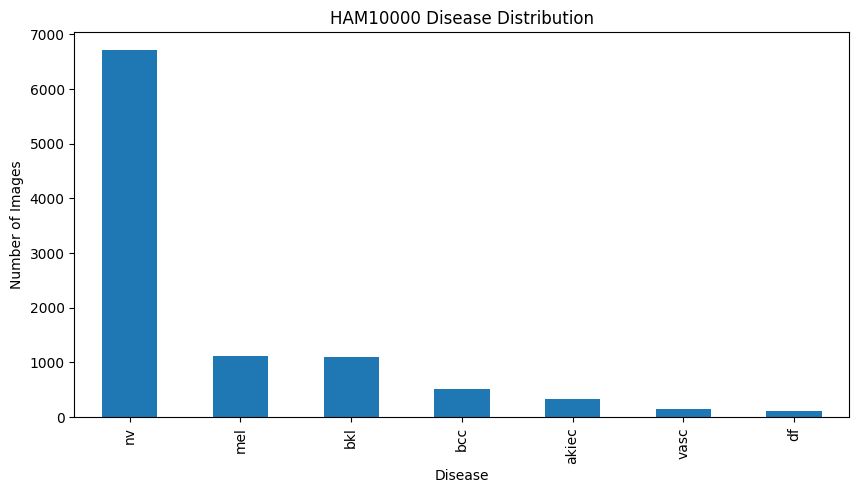

In [ ]:
df["dx"].value_counts().plot(
    kind="bar",
    figsize=(10, 5),
    title="HAM10000 Disease Distribution"
)

plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["dx"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["dx"],
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 8012
Validation: 1001
Testing: 1002


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df["dx"])
val_df["label"] = label_encoder.transform(val_df["dx"])
test_df["label"] = label_encoder.transform(test_df["dx"])

print("Classes:")
for i, name in enumerate(label_encoder.classes_):
    print(i, "→", name)

Classes:
0 → akiec
1 → bcc
2 → bkl
3 → df
4 → mel
5 → nv
6 → vasc


In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(label_encoder.classes_)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

Image size: 224
Batch size: 32
Number of classes: 7


In [ ]:
import tensorflow as tf

def create_dataset(dataframe, shuffle=False):
    paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
        image = tf.cast(image, tf.float32)

        return image, label

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(2000)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

print("Datasets created successfully!")

Datasets created successfully!


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
for class_id, weight in class_weights.items():
    print(
        label_encoder.inverse_transform([class_id])[0],
        "→",
        round(weight, 3)
    )

Class weights:
akiec → 4.369
bcc → 2.785
bkl → 1.302
df → 12.441
mel → 1.286
nv → 0.213
vasc → 10.04


In [ ]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 1125s 3s/step - accuracy: 0.4376 - loss: 1.6082 - val_accuracy: 0.6214 - val_loss: 1.1139
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 73s 233ms/step - accuracy: 0.5397 - loss: 1.3039 - val_accuracy: 0.5874 - val_loss: 1.1254
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 227ms/step - accuracy: 0.5502 - loss: 1.2205 - val_accuracy: 0.6434 - val_loss: 0.9496
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 73s 195ms/step - accuracy: 0.5749 - loss: 1.1680 - val_accuracy: 0.6364 - val_loss: 0.9973
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 67s 220ms/step - accuracy: 0.5836 - loss: 1.1106 - val_accuracy: 0.6444 - val_loss: 0.9902
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 83s 220ms/step - accuracy: 0.5992 - loss: 1.0696 - val_accuracy: 0.6164 - val_loss: 1.0066
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 81s 218ms/step - accuracy: 0.5990 - loss: 1.0434 - val_accuracy: 0.6424 - val_loss: 0.9649
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 201ms/step - accuracy: 0.6126 - loss: 1.

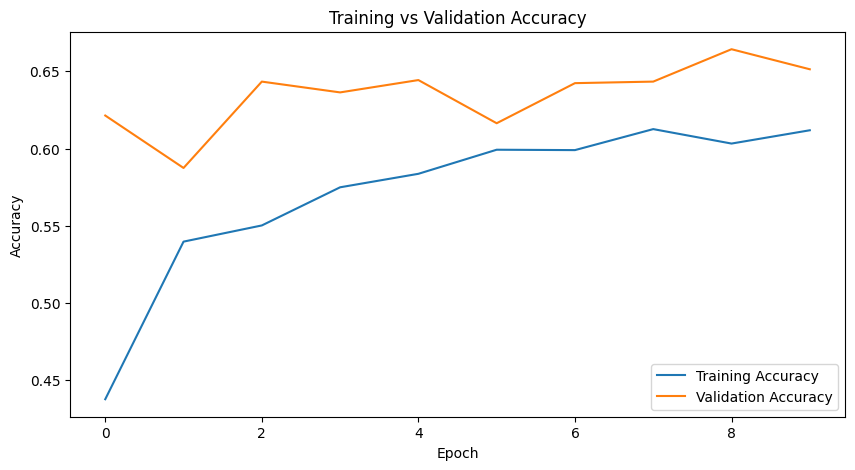

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

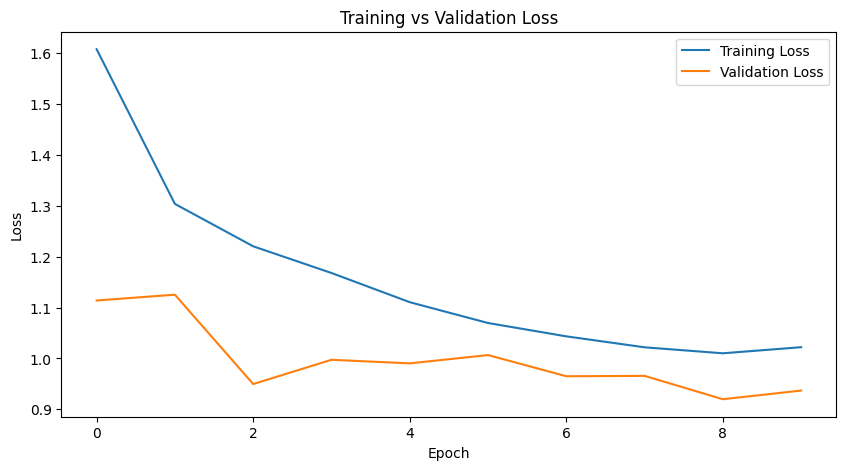

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 133s 4s/step - accuracy: 0.6677 - loss: 0.8921
Test Loss: 0.8920931220054626
Test Accuracy: 0.667664647102356


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    digits=4
))

              precision    recall  f1-score   support

       akiec     0.5263    0.3125    0.3922        32
         bcc     0.4898    0.4615    0.4752        52
         bkl     0.4908    0.7273    0.5861       110
          df     0.1818    0.7273    0.2909        11
         mel     0.2842    0.4643    0.3525       112
          nv     0.9323    0.7183    0.8114       671
        vasc     0.4815    0.9286    0.6341        14

    accuracy                         0.6677      1002
   macro avg     0.4838    0.6200    0.5061      1002
weighted avg     0.7609    0.6677    0.6964      1002



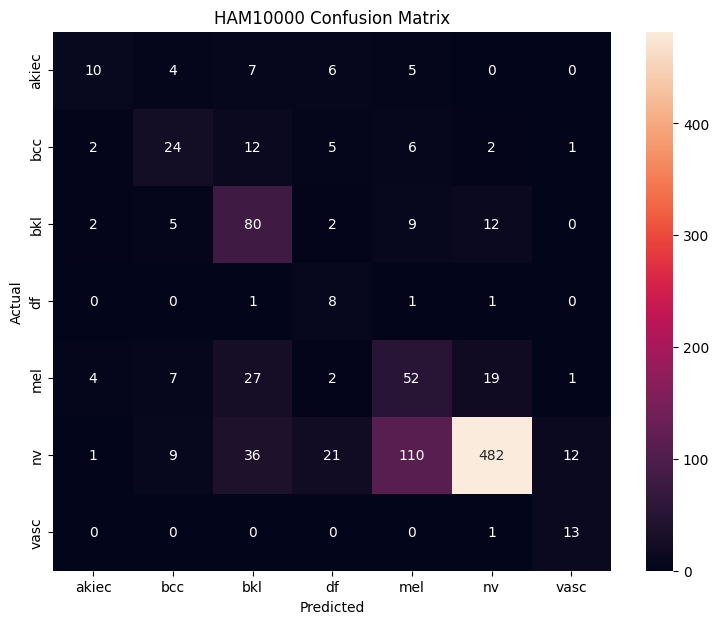

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("HAM10000 Confusion Matrix")
plt.show()

In [ ]:
# Unfreeze the EfficientNet base model
base_model.trainable = True

# Freeze the earlier layers and only fine-tune the later layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

NameError: name 'base_model' is not defined

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled successfully!")

NameError: name 'model' is not defined

In [ ]:
FINE_TUNE_EPOCHS = 5

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights
)

NameError: name 'model' is not defined

In [ ]:
fine_test_loss, fine_test_accuracy = model.evaluate(test_ds)

print("Fine-tuned Test Loss:", fine_test_loss)
print("Fine-tuned Test Accuracy:", fine_test_accuracy)

NameError: name 'model' is not defined

In [ ]:
print("test")

test


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os
import glob

base = "/content/drive/MyDrive/DermaWise/data/ham10000"

df = pd.read_csv(base + "/HAM10000_metadata.csv")

folder1 = base + "/HAM10000_images_part_1"
folder2 = base + "/HAM10000_images_part_2"

image_paths = {}

for path in glob.glob(folder1 + "/*.jpg") + glob.glob(folder2 + "/*.jpg"):
    image_id = os.path.splitext(os.path.basename(path))[0]
    image_paths[image_id] = path

df["image_path"] = df["image_id"].map(image_paths)

print("Records:", len(df))
print("Matched:", df["image_path"].notna().sum())

Records: 10015
Matched: 10015


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["dx"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["dx"],
    random_state=42
)

label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df["dx"])
val_df["label"] = label_encoder.transform(val_df["dx"])
test_df["label"] = label_encoder.transform(test_df["dx"])

print(len(train_df), len(val_df), len(test_df))

8012 1001 1002


In [ ]:
import os

model_dir = "/content/drive/MyDrive/DermaWise/models"

print(
    os.listdir(model_dir)
    if os.path.exists(model_dir)
    else "NO SAVED MODEL"
)

NO SAVED MODEL


In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe["image_path"].values, dataframe["label"].values)
    )

    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(2000)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Datasets recreated successfully")

Datasets recreated successfully


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

NUM_CLASSES = 7

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recreated successfully")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model recreated successfully


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(4.368593238822246), np.int64(1): np.float64(2.7848453249913105), np.int64(2): np.float64(1.3021290427433772), np.int64(3): np.float64(12.440993788819876), np.int64(4): np.float64(1.2860353130016051), np.int64(5): np.float64(0.21338020666879728), np.int64(6): np.float64(10.040100250626567)}


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(4.368593238822246), np.int64(1): np.float64(2.7848453249913105), np.int64(2): np.float64(1.3021290427433772), np.int64(3): np.float64(12.440993788819876), np.int64(4): np.float64(1.2860353130016051), np.int64(5): np.float64(0.21338020666879728), np.int64(6): np.float64(10.040100250626567)}


In [ ]:
import os

model_dir = "/content/drive/MyDrive/DermaWise/models"
os.makedirs(model_dir, exist_ok=True)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    model_dir + "/dermawise_baseline_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint]
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3371 - loss: 1.7980
Epoch 1: val_loss improved from None to 1.13046, saving model to /content/drive/MyDrive/DermaWise/models/dermawise_baseline_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DermaWise/models/dermawise_baseline_best.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 1309s 5s/step - accuracy: 0.4227 - loss: 1.6103 - val_accuracy: 0.5984 - val_loss: 1.1305
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.5378 - loss: 1.3466
Epoch 2: val_loss did not improve from 1.13046
251/251 ━━━━━━━━━━━━━━━━━━━━ 68s 222ms/step - accuracy: 0.5436 - loss: 1.3117 - val_accuracy: 0.5844 - val_loss: 1.1975
Epoch 3/10
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5633 - loss: 1.1988
Epoch 3: val_loss improved from 1.13046 to 1.05181, saving model to /content/drive/MyDrive/DermaWise/models/dermawise_baseline_best.keras

Epoch 3: finished saving model to /content/drive/MyDrive/DermaWise/models/

In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/DermaWise/models/dermawise_baseline_best.keras"
)

print("Best baseline model loaded")

Best baseline model loaded


In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 195s 6s/step - accuracy: 0.6846 - loss: 0.8649
Test Loss: 0.864913821220398
Test Accuracy: 0.6846307516098022


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    digits=4
))

              precision    recall  f1-score   support

       akiec     0.6429    0.2812    0.3913        32
         bcc     0.5278    0.3654    0.4318        52
         bkl     0.5203    0.7000    0.5969       110
          df     0.2571    0.8182    0.3913        11
         mel     0.2995    0.5268    0.3819       112
          nv     0.9242    0.7452    0.8251       671
        vasc     0.4194    0.9286    0.5778        14

    accuracy                         0.6846      1002
   macro avg     0.5130    0.6236    0.5137      1002
weighted avg     0.7661    0.6846    0.7080      1002



In [ ]:
# Unfreeze EfficientNet
base_model = None

# Find the EfficientNet layer inside the loaded model
for layer in model.layers:
    if "efficientnet" in layer.name.lower():
        base_model = layer
        break

print("Base model:", base_model.name)

Base model: efficientnetb0


In [ ]:
base_model.trainable = True

# Keep most layers frozen
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Fine-tuning enabled")
print(
    "Trainable base layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Fine-tuning enabled
Trainable base layers: 23


In [ ]:
fine_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/DermaWise/models/dermawise_finetuned_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights,
    callbacks=[fine_checkpoint, early_stop]
)

Epoch 1/8


ValueError: Unknown variable: <Variable path=block6d_dwconv/kernel, shape=(5, 5, 1152, 1), dtype=float32>. This optimizer can only be called for the variables it was originally built with. When working with a new set of variables, you should recreate a new optimizer instance.

In [ ]:
# Recompile with a completely new optimizer instance
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning")

Model recompiled for fine-tuning


In [ ]:
fine_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/DermaWise/models/dermawise_finetuned_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights,
    callbacks=[fine_checkpoint, early_stop]
)

Epoch 1/8
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.6265 - loss: 1.0244
Epoch 1: val_loss improved from None to 0.91400, saving model to /content/drive/MyDrive/DermaWise/models/dermawise_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DermaWise/models/dermawise_finetuned_best.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 85s 241ms/step - accuracy: 0.6289 - loss: 0.9819 - val_accuracy: 0.6563 - val_loss: 0.9140
Epoch 2/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.6487 - loss: 0.9418
Epoch 2: val_loss improved from 0.91400 to 0.89344, saving model to /content/drive/MyDrive/DermaWise/models/dermawise_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DermaWise/models/dermawise_finetuned_best.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 64s 204ms/step - accuracy: 0.6395 - loss: 0.9423 - val_accuracy: 0.6623 - val_loss: 0.8934
Epoch 3/8
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.6419 - loss: 0.9537
Epoch 3: val

In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/DermaWise/models/dermawise_baseline_best.keras"
)

In [ ]:
base_model = None

for layer in model.layers:
    if "efficientnet" in layer.name.lower():
        base_model = layer
        break

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
fine_test_loss, fine_test_accuracy = model.evaluate(test_ds)

print("Fine-Tuned Test Loss:", fine_test_loss)
print("Fine-Tuned Test Accuracy:", fine_test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 247ms/step - accuracy: 0.6846 - loss: 0.8649
Fine-Tuned Test Loss: 0.864913821220398
Fine-Tuned Test Accuracy: 0.6846307516098022


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    digits=4
))

              precision    recall  f1-score   support

       akiec     0.6429    0.2812    0.3913        32
         bcc     0.5278    0.3654    0.4318        52
         bkl     0.5203    0.7000    0.5969       110
          df     0.2571    0.8182    0.3913        11
         mel     0.2995    0.5268    0.3819       112
          nv     0.9242    0.7452    0.8251       671
        vasc     0.4194    0.9286    0.5778        14

    accuracy                         0.6846      1002
   macro avg     0.5130    0.6236    0.5137      1002
weighted avg     0.7661    0.6846    0.7080      1002



In [ ]:
from google.colab import files

uploaded = files.upload()

Saving burn.JPG to burn.JPG


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


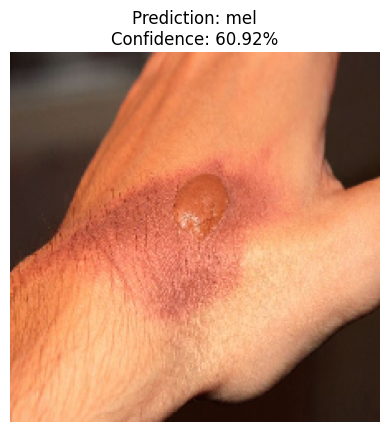

Predicted class: mel
Confidence: 60.92%


In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

# Automatically gets the image you just uploaded
uploaded_image = list(uploaded.keys())[0]

img = image.load_img(
    uploaded_image,
    target_size=(224, 224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction[0])
confidence = prediction[0][predicted_class]

disease = label_encoder.inverse_transform(
    [predicted_class]
)[0]

plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {disease}\nConfidence: {confidence:.2%}"
)
plt.show()

print("Predicted class:", disease)
print("Confidence:", f"{confidence:.2%}")

In [ ]:
class_names = {
    "akiec": "Actinic Keratosis",
    "bcc": "Basal Cell Carcinoma",
    "bkl": "Benign Keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic Nevus",
    "vasc": "Vascular Lesion"
}

readable_name = class_names[disease]

print("Prediction:", readable_name)
print("Confidence:", f"{confidence:.2%}")

Prediction: Melanoma
Confidence: 60.92%


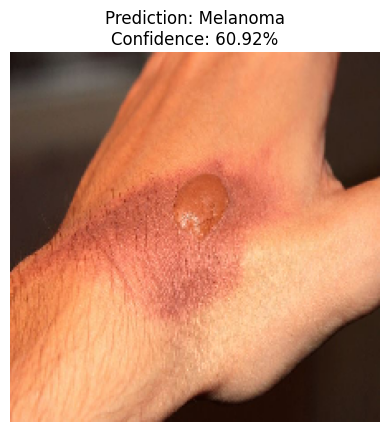

In [ ]:
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {readable_name}\nConfidence: {confidence:.2%}"
)
plt.show()

In [ ]:
base_model = None

for layer in model.layers:
    if "efficientnet" in layer.name.lower():
        base_model = layer
        break

print("Base model:", base_model.name)
print("Last layer:", base_model.layers[-1].name)

Base model: efficientnetb0
Last layer: top_activation


In [ ]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model, base_model, pred_index=None):

    # Last convolutional layer in EfficientNet
    last_conv_layer = None

    for layer in reversed(base_model.layers):
        try:
            if len(layer.output.shape) == 4:
                last_conv_layer = layer
                break
        except:
            pass

    print("Grad-CAM layer:", last_conv_layer.name)

    # Model that outputs both:
    # convolutional features + final predictions
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            last_conv_layer.output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.math.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy()

In [ ]:
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    base_model
)

print("Heatmap created successfully")

Grad-CAM layer: top_activation


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m136026507418096\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[ 27.,  17.,  15.],\n         [ 29.,  19.,  17.],\n         [ 33.,  23.,  21.],\n         ...,\n         [ 50.,  35.,  28.],\n         [ 50.,  35.,  28.],\n         [ 50.,  35.,  28.]],\n\n        [[ 27.,  17.,  15.],\n         [ 29.,  19.,  17.],\n         [ 32.,  22.,  20.],\n         ...,\n         [ 50.,  35.,  28.],\n         [ 50.,  35.,  28.],\n         [ 50.,  35.,  28.]],\n\n        [[ 27.,  17.,  15.],\n         [ 29.,  19.,  17.],\n         [ 31.,  21.,  19.],\n         ...,\n         [ 50.,  35.,  28.],\n         [ 50.,  35.,  28.],\n         [ 50.,  35.,  28.]],\n\n        ...,\n\n        [[236., 139.,  96.],\n         [250., 168., 120.],\n         [255., 185., 133.],\n         ...,\n         [ 43.,  26.,  18.],\n         [ 44.,  27.,  19.],\n         [ 45.,  28.,  20.]],\n\n        [[241., 146.,  98.],\n        

In [ ]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model, base_model, pred_index=None):

    # Find last 4D convolutional feature layer
    last_conv_layer = None

    for layer in reversed(base_model.layers):
        try:
            if len(layer.output.shape) == 4:
                last_conv_layer = layer
                break
        except:
            continue

    print("Grad-CAM layer:", last_conv_layer.name)

    # Create feature extractor INSIDE EfficientNet
    feature_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[
            last_conv_layer.output,
            base_model.output
        ]
    )

    # Find where EfficientNet sits inside our full model
    base_index = model.layers.index(base_model)

    # Convert uploaded image to Tensor
    input_tensor = tf.convert_to_tensor(
        img_array,
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:

        # Run layers BEFORE EfficientNet
        x = input_tensor

        for layer in model.layers[1:base_index]:
            x = layer(x, training=False)

        # Get EfficientNet convolution features
        conv_outputs, x = feature_model(
            x,
            training=False
        )

        # Run layers AFTER EfficientNet
        for layer in model.layers[base_index + 1:]:
            x = layer(x, training=False)

        predictions = x

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_score = predictions[:, pred_index]

    # Gradient of predicted class with respect to conv features
    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    # Weighted feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Remove negative values
    heatmap = tf.maximum(heatmap, 0)

    # Normalize 0–1
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy()

In [ ]:
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    base_model
)

print("Heatmap created successfully!")
print("Heatmap shape:", heatmap.shape)

Grad-CAM layer: top_activation
Heatmap created successfully!
Heatmap shape: (7, 7)


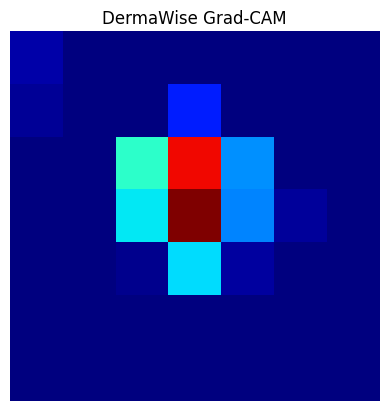

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(heatmap, cmap="jet")
plt.axis("off")
plt.title("DermaWise Grad-CAM")
plt.show()

/tmp/ipykernel_1409/3500578812.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


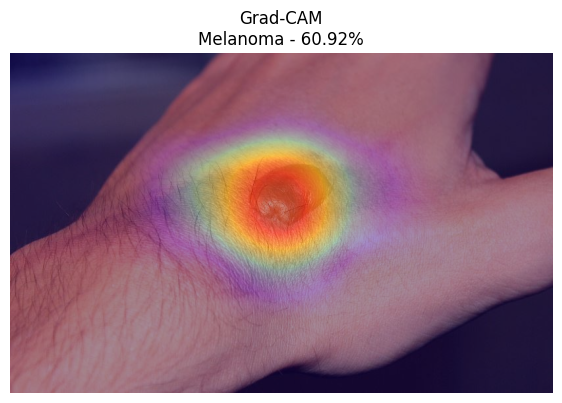

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from PIL import Image

# Load original uploaded image
original_img = image.load_img(uploaded_image)
original_array = image.img_to_array(original_img)

# Convert heatmap to image
heatmap_uint8 = np.uint8(255 * heatmap)
heatmap_img = Image.fromarray(heatmap_uint8)

# Resize heatmap to original image size
heatmap_img = heatmap_img.resize(
    (original_array.shape[1], original_array.shape[0])
)

heatmap_resized = np.array(heatmap_img) / 255.0

# Apply jet colormap
jet = cm.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]

colored_heatmap = jet_colors[
    np.uint8(255 * heatmap_resized)
]

# Overlay heatmap on original image
overlay = (
    0.65 * (original_array / 255.0)
    + 0.35 * colored_heatmap
)

overlay = np.clip(overlay, 0, 1)

# Display
plt.figure(figsize=(7, 7))
plt.imshow(overlay)
plt.axis("off")
plt.title(
    f"Grad-CAM\n{readable_name} - {confidence:.2%}"
)
plt.show()

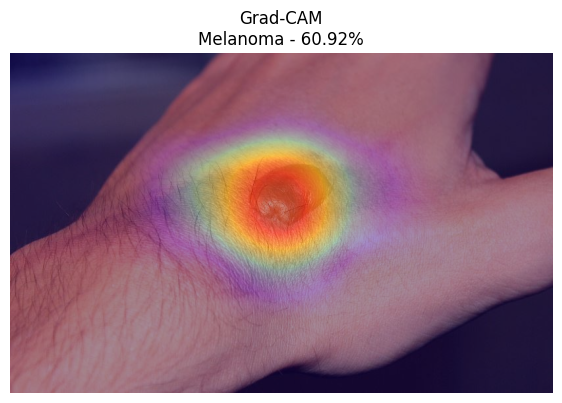

Saved to: /content/drive/MyDrive/DermaWise/gradcam_result.png


In [ ]:
plt.figure(figsize=(7, 7))
plt.imshow(overlay)
plt.axis("off")
plt.title(
    f"Grad-CAM\n{readable_name} - {confidence:.2%}"
)

save_path = "/content/drive/MyDrive/DermaWise/gradcam_result.png"

plt.savefig(
    save_path,
    bbox_inches="tight",
    dpi=300
)

plt.show()

print("Saved to:", save_path)

In [ ]:
print(df.columns)

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image_path'],
      dtype='object')


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# First split: 80% train, 20% temporary
gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, temp_idx = next(
    gss1.split(
        df,
        groups=df["lesion_id"]
    )
)

train_df_grouped = df.iloc[train_idx].copy()
temp_df_grouped = df.iloc[temp_idx].copy()

# Second split: temporary -> 50% validation, 50% test
gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(
        temp_df_grouped,
        groups=temp_df_grouped["lesion_id"]
    )
)

val_df_grouped = temp_df_grouped.iloc[val_idx].copy()
test_df_grouped = temp_df_grouped.iloc[test_idx].copy()

print("Train:", len(train_df_grouped))
print("Validation:", len(val_df_grouped))
print("Test:", len(test_df_grouped))

Train: 7991
Validation: 1025
Test: 999


In [ ]:
train_lesions = set(train_df_grouped["lesion_id"])
val_lesions = set(val_df_grouped["lesion_id"])
test_lesions = set(test_df_grouped["lesion_id"])

print(
    "Train-Val overlap:",
    len(train_lesions.intersection(val_lesions))
)

print(
    "Train-Test overlap:",
    len(train_lesions.intersection(test_lesions))
)

print(
    "Val-Test overlap:",
    len(val_lesions.intersection(test_lesions))
)

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df_grouped["label"] = label_encoder.fit_transform(
    train_df_grouped["dx"]
)

val_df_grouped["label"] = label_encoder.transform(
    val_df_grouped["dx"]
)

test_df_grouped["label"] = label_encoder.transform(
    test_df_grouped["dx"]
)

print("Classes:", label_encoder.classes_)

Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["image_path"].values,
            dataframe["label"].values
        )
    )

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(2000)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds_grouped = make_dataset(
    train_df_grouped,
    training=True
)

val_ds_grouped = make_dataset(
    val_df_grouped
)

test_ds_grouped = make_dataset(
    test_df_grouped
)

print("Grouped datasets ready")

Grouped datasets ready


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df_grouped["label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df_grouped["label"]
)

class_weights_grouped = dict(
    zip(classes, weights)
)

print(class_weights_grouped)

{np.int64(0): np.float64(4.390659340659341), np.int64(1): np.float64(2.6923854447439353), np.int64(2): np.float64(1.333611481975968), np.int64(3): np.float64(11.76877761413844), np.int64(4): np.float64(1.3016777976869196), np.int64(5): np.float64(0.21262272836122714), np.int64(6): np.float64(10.57010582010582)}


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

NUM_CLASSES = len(label_encoder.classes_)

base_model_grouped = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model_grouped.trainable = False

inputs = tf.keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = data_augmentation(inputs)
x = base_model_grouped(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model_grouped = tf.keras.Model(
    inputs,
    outputs
)

model_grouped.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Grouped baseline model ready")

Grouped baseline model ready


In [ ]:
import os

model_dir = "/content/drive/MyDrive/DermaWise/models"
os.makedirs(model_dir, exist_ok=True)

grouped_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    model_dir + "/dermawise_grouped_baseline_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [ ]:
history_grouped = model_grouped.fit(
    train_ds_grouped,
    validation_data=val_ds_grouped,
    epochs=10,
    class_weight=class_weights_grouped,
    callbacks=[grouped_checkpoint]
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.4097 - loss: 2.4570
Epoch 1: val_loss improved from None to 1.33545, saving model to /content/drive/MyDrive/DermaWise/models/dermawise_grouped_baseline_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DermaWise/models/dermawise_grouped_baseline_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 234ms/step - accuracy: 0.5270 - loss: 1.5785 - val_accuracy: 0.5366 - val_loss: 1.3354
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.4300 - loss: 2.1626
Epoch 2: val_loss improved from 1.33545 to 1.19260, saving model to /content/drive/MyDrive/DermaWise/models/dermawise_grouped_baseline_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DermaWise/models/dermawise_grouped_baseline_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 74s 205ms/step - accuracy: 0.5708 - loss: 1.2954 - val_accuracy: 0.6195 - val_loss: 1.1926
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.4

In [ ]:
model_grouped = tf.keras.models.load_model(
    "/content/drive/MyDrive/DermaWise/models/dermawise_grouped_baseline_best.keras"
)

print("Best grouped model loaded")

Best grouped model loaded


In [ ]:
grouped_test_loss, grouped_test_accuracy = model_grouped.evaluate(
    test_ds_grouped
)

print("Grouped Test Loss:", grouped_test_loss)
print("Grouped Test Accuracy:", grouped_test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 327ms/step - accuracy: 0.6957 - loss: 0.8801
Grouped Test Loss: 0.8801472187042236
Grouped Test Accuracy: 0.695695698261261


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true_grouped = []
y_pred_grouped = []

for images, labels in test_ds_grouped:
    predictions = model_grouped.predict(images, verbose=0)

    y_true_grouped.extend(labels.numpy())
    y_pred_grouped.extend(
        np.argmax(predictions, axis=1)
    )

y_true_grouped = np.array(y_true_grouped)
y_pred_grouped = np.array(y_pred_grouped)

print(
    classification_report(
        y_true_grouped,
        y_pred_grouped,
        target_names=label_encoder.classes_,
        digits=4
    )
)

              precision    recall  f1-score   support

       akiec     0.2000    0.8889    0.3265        36
         bcc     1.0000    0.1395    0.2449        43
         bkl     0.6875    0.1560    0.2543       141
          df     0.0588    0.1111    0.0769         9
         mel     0.4634    0.1863    0.2657       102
          nv     0.8297    0.9255    0.8750       658
        vasc     0.6667    0.6000    0.6316        10

    accuracy                         0.6957       999
   macro avg     0.5580    0.4296    0.3821       999
weighted avg     0.7483    0.6957    0.6687       999



In [ ]:
# Find EfficientNet inside the grouped model
base_model_grouped = None

for layer in model_grouped.layers:
    if "efficientnet" in layer.name.lower():
        base_model_grouped = layer
        break

print("Base model:", base_model_grouped.name)

Base model: efficientnetb0


In [ ]:
# Unfreeze EfficientNet
base_model_grouped.trainable = True

# Only fine-tune the last 30 layers
for layer in base_model_grouped.layers[:-30]:
    layer.trainable = False

# Keep BatchNormalization frozen
for layer in base_model_grouped.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print(
    "Trainable EfficientNet layers:",
    sum(layer.trainable for layer in base_model_grouped.layers)
)

Trainable EfficientNet layers: 23


In [ ]:
model_grouped.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Grouped model ready for fine-tuning")

Grouped model ready for fine-tuning


In [ ]:
fine_grouped_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/DermaWise/models/dermawise_grouped_finetuned_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history_grouped_fine = model_grouped.fit(
    train_ds_grouped,
    validation_data=val_ds_grouped,
    epochs=8,
    class_weight=class_weights_grouped,
    callbacks=[
        fine_grouped_checkpoint,
        early_stop
    ]
)

Epoch 1/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.5342 - loss: 2.0305
Epoch 1: val_loss improved from None to 0.94378, saving model to /content/drive/MyDrive/DermaWise/models/dermawise_grouped_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DermaWise/models/dermawise_grouped_finetuned_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 84s 242ms/step - accuracy: 0.6208 - loss: 1.1612 - val_accuracy: 0.6663 - val_loss: 0.9438
Epoch 2/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5793 - loss: 1.6543
Epoch 2: val_loss improved from 0.94378 to 0.93135, saving model to /content/drive/MyDrive/DermaWise/models/dermawise_grouped_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DermaWise/models/dermawise_grouped_finetuned_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 70s 228ms/step - accuracy: 0.6446 - loss: 1.0263 - val_accuracy: 0.6732 - val_loss: 0.9313
Epoch 3/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.

In [ ]:
model_grouped_fine = tf.keras.models.load_model(
    "/content/drive/MyDrive/DermaWise/models/dermawise_grouped_finetuned_best.keras"
)

print("Best fine-tuned grouped model loaded")

Best fine-tuned grouped model loaded


In [ ]:
fine_loss, fine_accuracy = model_grouped_fine.evaluate(
    test_ds_grouped
)

print("Fine-Tuned Grouped Test Loss:", fine_loss)
print("Fine-Tuned Grouped Test Accuracy:", fine_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 328ms/step - accuracy: 0.7167 - loss: 0.7671
Fine-Tuned Grouped Test Loss: 0.7670618295669556
Fine-Tuned Grouped Test Accuracy: 0.7167167067527771


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true_fine = []
y_pred_fine = []

for images, labels in test_ds_grouped:
    predictions = model_grouped_fine.predict(
        images,
        verbose=0
    )

    y_true_fine.extend(labels.numpy())
    y_pred_fine.extend(
        np.argmax(predictions, axis=1)
    )

y_true_fine = np.array(y_true_fine)
y_pred_fine = np.array(y_pred_fine)

print(
    classification_report(
        y_true_fine,
        y_pred_fine,
        target_names=label_encoder.classes_,
        digits=4
    )
)

              precision    recall  f1-score   support

       akiec     0.2521    0.8333    0.3871        36
         bcc     0.8636    0.4419    0.5846        43
         bkl     0.6404    0.4043    0.4957       141
          df     0.1667    0.4444    0.2424         9
         mel     0.3651    0.4510    0.4035       102
          nv     0.9052    0.8419    0.8724       658
        vasc     0.8571    0.6000    0.7059        10

    accuracy                         0.7167       999
   macro avg     0.5786    0.5738    0.5274       999
weighted avg     0.7802    0.7167    0.7342       999



In [ ]:
import os

model_path = "/content/drive/MyDrive/DermaWise/models/dermawise_grouped_finetuned_best.keras"

if os.path.exists(model_path):
    print("✅ MODEL IS SAVED")
    print("Location:", model_path)
    print("Size:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")
else:
    print("❌ Model not found")

✅ MODEL IS SAVED
Location: /content/drive/MyDrive/DermaWise/models/dermawise_grouped_finetuned_best.keras
Size: 27.69 MB


In [ ]:
import tensorflow as tf

final_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/DermaWise/models/dermawise_grouped_finetuned_best.keras"
)

print("Final DermaWise model loaded successfully")

Final DermaWise model loaded successfully


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving burn.JPG to burn (1).JPG


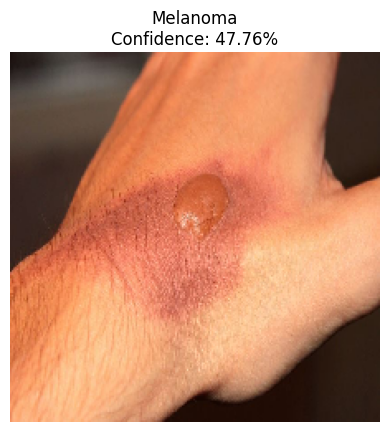

Prediction: Melanoma
Confidence: 47.76%


In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

uploaded_image = list(uploaded.keys())[0]

img = image.load_img(
    uploaded_image,
    target_size=(224, 224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = final_model.predict(img_array, verbose=0)

predicted_class = np.argmax(prediction[0])
confidence = prediction[0][predicted_class]

disease_code = label_encoder.inverse_transform(
    [predicted_class]
)[0]

class_names = {
    "akiec": "Actinic Keratosis",
    "bcc": "Basal Cell Carcinoma",
    "bkl": "Benign Keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic Nevus",
    "vasc": "Vascular Lesion"
}

readable_name = class_names[disease_code]

plt.imshow(img)
plt.axis("off")
plt.title(
    f"{readable_name}\nConfidence: {confidence:.2%}"
)
plt.show()

print("Prediction:", readable_name)
print("Confidence:", f"{confidence:.2%}")

In [ ]:
for i, prob in enumerate(prediction[0]):
    code = label_encoder.inverse_transform([i])[0]
    print(
        f"{class_names[code]}: {prob * 100:.2f}%"
    )

Actinic Keratosis: 0.92%
Basal Cell Carcinoma: 2.79%
Benign Keratosis: 25.50%
Dermatofibroma: 3.62%
Melanoma: 47.76%
Melanocytic Nevus: 19.37%
Vascular Lesion: 0.04%


In [ ]:
# Show all class probabilities
results = []

for i, prob in enumerate(prediction[0]):
    code = label_encoder.inverse_transform([i])[0]
    results.append(
        (class_names[code], float(prob))
    )

results = sorted(
    results,
    key=lambda x: x[1],
    reverse=True
)

for name, prob in results:
    print(f"{name}: {prob * 100:.2f}%")

Melanoma: 47.76%
Benign Keratosis: 25.50%
Melanocytic Nevus: 19.37%
Dermatofibroma: 3.62%
Basal Cell Carcinoma: 2.79%
Actinic Keratosis: 0.92%
Vascular Lesion: 0.04%


In [ ]:
top_name, top_prob = results[0]

CONFIDENCE_THRESHOLD = 0.60

if top_prob < CONFIDENCE_THRESHOLD:
    print("\n⚠️ Result: UNCERTAIN")
    print("The image does not closely match the model's learned patterns.")
    print("Please use a clear lesion image or seek professional evaluation.")
else:
    print("\nPrediction:", top_name)
    print("Confidence:", f"{top_prob * 100:.2f}%")


⚠️ Result: UNCERTAIN
The image does not closely match the model's learned patterns.
Please use a clear lesion image or seek professional evaluation.


In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/DermaWise/models/dermawise_grouped_finetuned_best.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DERMAWISE - FITZPATRICK / SKIN-TONE FAIRNESS EVALUATION

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("Fairness evaluation section ready.")

Fairness evaluation section ready.


In [3]:
import pandas as pd

FITZ_CSV_URL = (
    "https://raw.githubusercontent.com/"
    "mattgroh/fitzpatrick17k/main/fitzpatrick17k.csv"
)

fitz_df = pd.read_csv(FITZ_CSV_URL)

print("Dataset loaded successfully.")
print("Number of rows:", len(fitz_df))

print("\nColumns:")
print(fitz_df.columns.tolist())

print("\nFirst 5 rows:")
display(fitz_df.head())

print("\nFitzpatrick label counts:")
print(
    fitz_df["fitzpatrick_scale"]
    .value_counts(dropna=False)
    .sort_index()
)

Dataset loaded successfully.
Number of rows: 16577

Columns:
['md5hash', 'fitzpatrick_scale', 'fitzpatrick_centaur', 'label', 'nine_partition_label', 'three_partition_label', 'qc', 'url', 'url_alphanum']

First 5 rows:


,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...



Fitzpatrick label counts:
fitzpatrick_scale
-1     565
 1    2947
 2    4808
 3    3308
 4    2781
 5    1533
 6     635
Name: count, dtype: int64


In [4]:
# ============================================================
# DERMAWISE - CHECK FITZPATRICK17K CLASS COMPATIBILITY
# ============================================================

# Show all unique diagnosis labels
fitz_labels = sorted(
    fitz_df["label"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.strip()
    .unique()
)

print("Total unique Fitzpatrick17k diagnoses:", len(fitz_labels))

# Terms related to DermaWise's 7 HAM10000 classes
search_terms = [
    "melanoma",
    "basal cell",
    "actinic",
    "keratosis",
    "dermatofibroma",
    "nevus",
    "nevi",
    "vascular",
    "angioma",
]

matched_labels = [
    label
    for label in fitz_labels
    if any(term in label for term in search_terms)
]

print("\nPotentially compatible diagnoses:")
for label in matched_labels:
    count = (
        fitz_df["label"]
        .astype(str)
        .str.lower()
        .str.strip()
        .eq(label)
        .sum()
    )

    print(f"{label}: {count}")

Total unique Fitzpatrick17k diagnoses: 114

Potentially compatible diagnoses:
actinic keratosis: 175
basal cell carcinoma: 468
basal cell carcinoma morpheiform: 62
becker nevus: 63
congenital nevus: 68
dermatofibroma: 79
disseminated actinic porokeratosis: 60
epidermal nevus: 91
halo nevus: 82
keratosis pilaris: 78
lymphangioma: 100
malignant melanoma: 111
melanoma: 261
nevocytic nevus: 86
nevus sebaceous of jadassohn: 95
porokeratosis actinic: 183
porokeratosis of mibelli: 78
seborrheic keratosis: 69
solid cystic basal cell carcinoma: 66
superficial spreading melanoma ssm: 118


In [5]:
# ============================================================
# DERMAWISE - CREATE FITZPATRICK17K COMPATIBLE SUBSET
# ============================================================

# Conservative mapping from Fitzpatrick17k diagnoses
# to DermaWise HAM10000 classes
FITZ_TO_DERMAWISE = {
    "actinic keratosis": "akiec",

    "basal cell carcinoma": "bcc",

    "seborrheic keratosis": "bkl",

    "dermatofibroma": "df",

    "melanoma": "mel",
    "malignant melanoma": "mel",
    "superficial spreading melanoma ssm": "mel",

    "nevocytic nevus": "nv",
}

# Clean diagnosis names
fitz_df["label_clean"] = (
    fitz_df["label"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Keep only compatible diagnoses
fairness_df = fitz_df[
    fitz_df["label_clean"].isin(FITZ_TO_DERMAWISE.keys())
].copy()

# Map them to DermaWise classes
fairness_df["dermawise_class"] = (
    fairness_df["label_clean"]
    .map(FITZ_TO_DERMAWISE)
)

# Remove unknown Fitzpatrick value (-1)
fairness_df = fairness_df[
    fairness_df["fitzpatrick_scale"].isin([1, 2, 3, 4, 5, 6])
].copy()

print("Compatible images after filtering:", len(fairness_df))

print("\nImages by DermaWise class:")
print(
    fairness_df["dermawise_class"]
    .value_counts()
)

print("\nImages by Fitzpatrick skin type:")
print(
    fairness_df["fitzpatrick_scale"]
    .value_counts()
    .sort_index()
)

print("\nClass x Fitzpatrick distribution:")
display(
    pd.crosstab(
        fairness_df["dermawise_class"],
        fairness_df["fitzpatrick_scale"]
    )
)

Compatible images after filtering: 1324

Images by DermaWise class:
dermawise_class
mel      465
bcc      460
akiec    168
nv        85
df        78
bkl       68
Name: count, dtype: int64

Images by Fitzpatrick skin type:
fitzpatrick_scale
1    305
2    491
3    263
4    167
5     71
6     27
Name: count, dtype: int64

Class x Fitzpatrick distribution:


fitzpatrick_scale,1,2,3,4,5,6
dermawise_class,,,,,,
akiec,33,72,30,21,11,1
bcc,85,156,112,76,24,7
bkl,15,31,8,5,5,4
df,16,30,24,7,1,0
mel,119,171,80,52,29,14
nv,37,31,9,6,1,1


In [6]:
import os
import requests
from pathlib import Path
from tqdm.auto import tqdm

FITZ_IMAGE_DIR = "/content/fitzpatrick17k_dermawise"
os.makedirs(FITZ_IMAGE_DIR, exist_ok=True)

fairness_df["local_path"] = None
fairness_df["download_success"] = False

downloaded = 0
failed = 0

for idx, row in tqdm(
    fairness_df.iterrows(),
    total=len(fairness_df)
):
    url = row["url"]
    image_id = row["md5hash"]

    output_path = (
        Path(FITZ_IMAGE_DIR) /
        f"{image_id}.jpg"
    )

    try:
        response = requests.get(
            url,
            timeout=15,
            headers={
                "User-Agent": "Mozilla/5.0"
            }
        )

        response.raise_for_status()

        content_type = (
            response.headers
            .get("Content-Type", "")
            .lower()
        )

        if "image" not in content_type:
            raise ValueError(
                f"Not an image: {content_type}"
            )

        with open(output_path, "wb") as f:
            f.write(response.content)

        fairness_df.at[
            idx, "local_path"
        ] = str(output_path)

        fairness_df.at[
            idx, "download_success"
        ] = True

        downloaded += 1

    except Exception:
        failed += 1

print("\nDownload finished.")
print("Downloaded:", downloaded)
print("Failed:", failed)

  0%|          | 0/1324 [00:00<?, ?it/s]


Download finished.
Downloaded: 363
Failed: 961


In [7]:
evaluation_df = fairness_df[
    fairness_df["download_success"] == True
].copy()

print(
    "Images available for evaluation:",
    len(evaluation_df)
)

print("\nBy class:")
print(
    evaluation_df["dermawise_class"]
    .value_counts()
)

print("\nBy Fitzpatrick type:")
print(
    evaluation_df["fitzpatrick_scale"]
    .value_counts()
    .sort_index()
)

Images available for evaluation: 363

By class:
dermawise_class
bcc      253
mel       79
akiec     23
df         8
Name: count, dtype: int64

By Fitzpatrick type:
fitzpatrick_scale
1     29
2     89
3    110
4     90
5     37
6      8
Name: count, dtype: int64


In [8]:
MODEL_PATH = (
    "/content/drive/MyDrive/DermaWise/models/"
    "dermawise_grouped_finetuned_best.keras"
)

dermawise_model = tf.keras.models.load_model(
    MODEL_PATH
)

CLASS_CODES = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc",
]

print("DermaWise model loaded successfully.")

DermaWise model loaded successfully.


In [9]:
from PIL import Image
import numpy as np
from tqdm.auto import tqdm

predicted_classes = []
prediction_scores = []
valid_indices = []

for idx, row in tqdm(
    evaluation_df.iterrows(),
    total=len(evaluation_df)
):
    try:
        image = Image.open(
            row["local_path"]
        ).convert("RGB")

        image = image.resize((224, 224))

        image_array = np.asarray(
            image,
            dtype=np.float32
        )

        # Keep 0-255 input range because this matches
        # the existing DermaWise EfficientNet pipeline.
        image_array = np.expand_dims(
            image_array,
            axis=0
        )

        predictions = dermawise_model.predict(
            image_array,
            verbose=0
        )[0]

        predicted_index = int(
            np.argmax(predictions)
        )

        predicted_classes.append(
            CLASS_CODES[predicted_index]
        )

        prediction_scores.append(
            float(predictions[predicted_index])
        )

        valid_indices.append(idx)

    except Exception as e:
        print(
            "Skipped:",
            row["local_path"],
            str(e)[:100]
        )

evaluation_df = evaluation_df.loc[
    valid_indices
].copy()

evaluation_df["predicted_class"] = (
    predicted_classes
)

evaluation_df["prediction_score"] = (
    prediction_scores
)

evaluation_df["correct"] = (
    evaluation_df["dermawise_class"]
    ==
    evaluation_df["predicted_class"]
)

print("\nExternal evaluation completed.")
print(
    "Successfully evaluated:",
    len(evaluation_df)
)

print(
    "Overall external accuracy:",
    round(
        evaluation_df["correct"].mean() * 100,
        2
    ),
    "%"
)

  0%|          | 0/363 [00:00<?, ?it/s]


External evaluation completed.
Successfully evaluated: 363
Overall external accuracy: 23.14 %


In [10]:
fairness_results = (
    evaluation_df
    .groupby("fitzpatrick_scale")
    .agg(
        total_images=("correct", "size"),
        correct_predictions=("correct", "sum"),
        accuracy=("correct", "mean"),
        average_model_score=(
            "prediction_score",
            "mean"
        ),
    )
    .reset_index()
)

fairness_results["accuracy_percent"] = (
    fairness_results["accuracy"] * 100
)

fairness_results[
    "average_model_score_percent"
] = (
    fairness_results[
        "average_model_score"
    ] * 100
)

display(
    fairness_results[
        [
            "fitzpatrick_scale",
            "total_images",
            "correct_predictions",
            "accuracy_percent",
            "average_model_score_percent",
        ]
    ]
)

,fitzpatrick_scale,total_images,correct_predictions,accuracy_percent,average_model_score_percent
0,1,29,10,34.482759,53.027316
1,2,89,24,26.966292,50.579563
2,3,110,26,23.636364,50.554486
3,4,90,14,15.555556,50.333423
4,5,37,8,21.621622,53.148655
5,6,8,2,25.000000,49.246208


In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    fairness_results["fitzpatrick_scale"].astype(str),
    fairness_results["accuracy_percent"]
)

plt.xlabel("Fitzpatrick Skin Type")
plt.ylabel("External Accuracy (%)")
plt.title(
    "DermaWise External Performance by Fitzpatrick Skin Type"
)

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

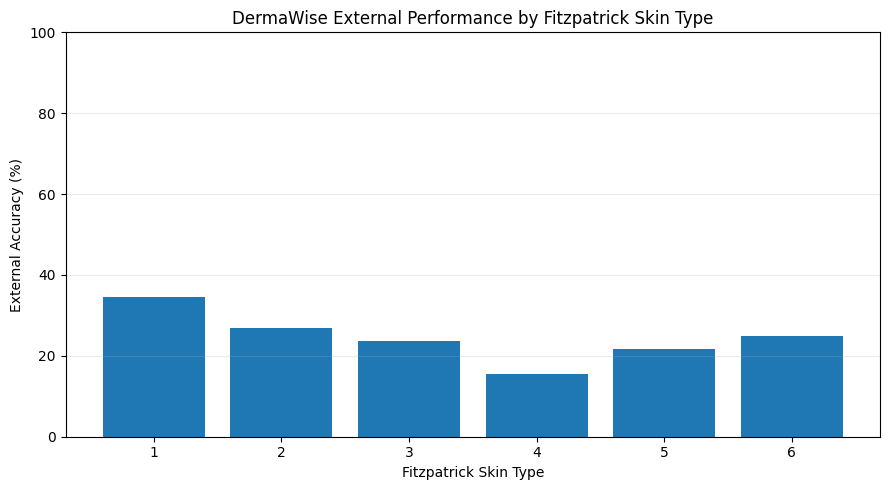

In [11]:
plt.figure(figsize=(9, 5))

plt.bar(
    fairness_results["fitzpatrick_scale"].astype(str),
    fairness_results["accuracy_percent"]
)

plt.xlabel("Fitzpatrick Skin Type")
plt.ylabel("External Accuracy (%)")
plt.title(
    "DermaWise External Performance by Fitzpatrick Skin Type"
)

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()